In [1]:
import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import eelbrain
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

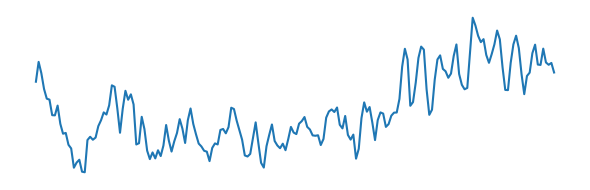

In [2]:
import eelbrain
import numpy as np
import matplotlib.pyplot as plt

SUB = 'S13'
dst_dir = file_paths.EEG_DIR / SUB
eeg_dst = dst_dir / f"{SUB}_eeg.pickle"

# Load NDVar
eeg = eelbrain.load.unpickle(eeg_dst)

# --- Select channels ---
channels = ['Cz', 'C1', 'C2', 'CPz']
eeg_sel = eeg.sub(sensor=channels)

# --- Crop first few seconds ---
eeg_crop = eeg_sel.sub(time=(0, 3))

# --- Average across channels ---
# First average across sensors, then across trials (if present)
avg_signal = eeg_crop.mean('sensor')

# If you have multiple trials (case dimension), average those too:
if 'case' in avg_signal.dims:
    avg_signal = avg_signal.mean('case')

# --- Extract time and data ---
times = avg_signal.time.times
data = avg_signal.x  # actual numpy array

# --- Plot ---
plt.figure(figsize=(6, 2))
plt.plot(times, data, linewidth=1.5)

plt.xticks([])
plt.yticks([])
plt.box(False)

plt.tight_layout()
plt.show()



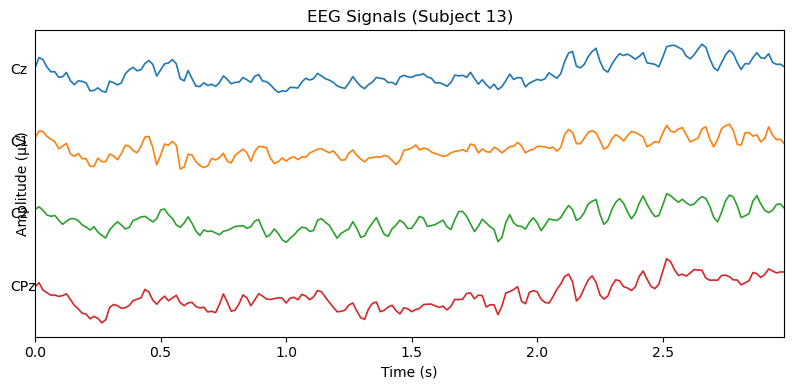

In [3]:
import eelbrain
import numpy as np
import matplotlib.pyplot as plt

SUB = 'S13'
dst_dir = file_paths.EEG_DIR / SUB
eeg_dst = dst_dir / f"{SUB}_eeg.pickle"

# Load NDVar
eeg = eelbrain.load.unpickle(eeg_dst)

# --- Select channels ---
channels = ['Cz', 'C1', 'C2', 'CPz']
eeg_sel = eeg.sub(sensor=channels)

# --- Crop first few seconds ---
eeg_crop = eeg_sel.sub(time=(0, 3))

# --- Average across trials if needed ---
if 'case' in eeg_crop.dims:
    eeg_crop = eeg_crop.mean('case')

# --- Extract data ---
data = eeg_crop.x.T   # <-- FIX HERE
times = eeg_crop.time.times

# Optional: convert to µV if needed
data = data * 1e6

# --- Plot ---
plt.figure(figsize=(8, 4))

offset = 0
spacing = np.max(np.abs(data)) * 2

for i, ch in enumerate(channels):
    signal = data[i]
    plt.plot(times, signal + offset, linewidth=1.2)
    
    # Channel label
    plt.text(times[0] - 0.1, offset, ch, va='center')
    
    offset -= spacing

# --- Labels ---
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("EEG Signals (Subject 13)")

plt.yticks([])
plt.xlim(times[0], times[-1])

plt.tight_layout()
plt.show()


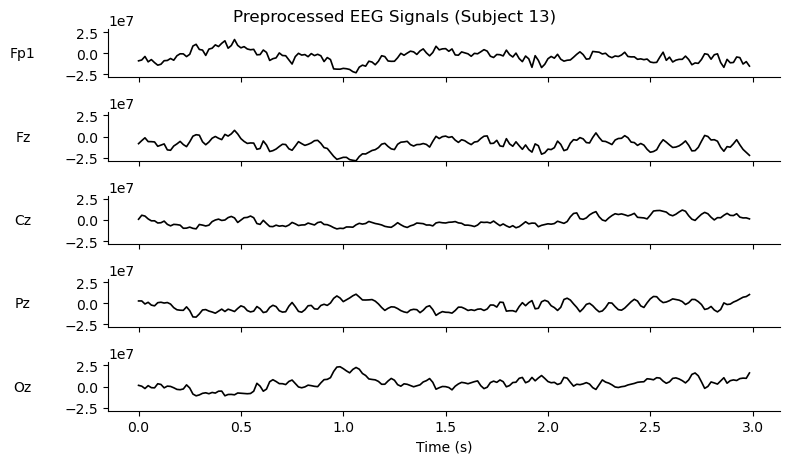

In [4]:
import eelbrain
import numpy as np
import matplotlib.pyplot as plt

SUB = 'S13'
dst_dir = file_paths.EEG_DIR / SUB
eeg_dst = dst_dir / f"{SUB}_eeg.pickle"

# Load NDVar
eeg = eelbrain.load.unpickle(eeg_dst)

# --- Select channels ---
channels = ['Fp1', 'Fz', 'Cz', 'Pz', 'Oz']
eeg_sel = eeg.sub(sensor=channels)

# --- Crop first few seconds ---
eeg_crop = eeg_sel.sub(time=(0, 3))

# --- Average across trials if needed ---
if 'case' in eeg_crop.dims:
    eeg_crop = eeg_crop.mean('case')

# --- Extract data ---
data = eeg_crop.x.T   # shape: (channels, time)
times = eeg_crop.time.times

# Optional: convert to µV
data = data * 1e6

# --- Compute global y-limits for all channels ---
ymax = np.max(np.abs(data))
ymin = -ymax

# --- Create subplots ---
fig, axes = plt.subplots(len(channels), 1, figsize=(8, 5), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(times, data[i], linewidth=1.2, color='black')
    
    # Channel label
    ax.set_ylabel(channels[i], rotation=0, labelpad=30, va='center')
    
    # Shared y-scale
    ax.set_ylim(ymin, ymax)
    
    # Clean style
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# X-axis
axes[-1].set_xlabel("Time (s)")

# Title
fig.suptitle("Preprocessed EEG Signals (Subject 13)", y=0.92)

plt.tight_layout()
plt.show()


In [5]:
import eelbrain
import numpy as np
import matplotlib.pyplot as plt

SUB = 'S13'
dst_dir = file_paths.EEG_DIR / SUB
eeg_dst = dst_dir / f"{SUB}_eeg.pickle"

# Load NDVar
eeg = eelbrain.load.unpickle(eeg_dst)

# --- Select channels ---
channels = ['Fp1', 'Fz', 'Cz', 'Pz', 'Oz']
eeg_sel = eeg.sub(sensor=channels)

# --- Crop first few seconds ---
eeg_crop = eeg_sel.sub(time=(0, 3))

# --- Average across trials if needed ---
if 'case' in eeg_crop.dims:
    eeg_crop = eeg_crop.mean('case')

# --- Extract data ---
data = eeg_crop.x.T
times = eeg_crop.time.times

# Convert to µV
data_uV = data * 1e6

# Determine scale from preprocessed EEG
ymax = np.max(np.abs(data_uV))
ymin = -ymax

# Create "raw" EEG without using actual preprocessed waveform
fake_raw = np.zeros_like(data_uV)

np.random.seed(42)
for i in range(len(channels)):
    n = data_uV.shape[1]
    
    # Base low-frequency drift
    drift = np.random.normal(0, 40, n).cumsum() / 50
    
    # High-frequency noise
    hf_noise = np.random.normal(0, 20, n)
    
    # Random spikes
    spikes = np.zeros(n)
    for _ in range(np.random.randint(5, 10)):
        start = np.random.randint(0, n-10)
        spike = np.hanning(10) * np.random.uniform(30, 80) * np.random.choice([-1,1])
        spikes[start:start+10] += spike
    
    # Random step offsets
    offsets = np.zeros(n)
    for _ in range(np.random.randint(2, 4)):
        step_start = np.random.randint(0, n-50)
        offsets[step_start:] += np.random.uniform(-30, 30)
    
    # Line noise
    line_noise = 10 * np.sin(2 * np.pi * 50 * times + np.random.rand()*2*np.pi)
    
    # Combine
    fake_raw[i] = drift + hf_noise + spikes + offsets + line_noise
    
    # Normalize to same amplitude as preprocessed
    fake_raw[i] = fake_raw[i] / np.max(np.abs(fake_raw[i])) * ymax


# --- Plot stacked mini-plots ---
fig, axes = plt.subplots(n_channels, 1, figsize=(8, 5), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(times, fake_raw[i], linewidth=1.2, color='black')
    
    # Channel label
    ax.set_ylabel(channels[i], rotation=0, labelpad=30, va='center')
    
    # Shared y-scale
    ax.set_ylim(ymin, ymax)
    
    # Clean style
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# X-axis
axes[-1].set_xlabel("Time (s)")

# Title
fig.suptitle("Raw EEG Signals (Subject 13)", y=0.92)

plt.tight_layout()
plt.show()


NameError: name 'n_channels' is not defined

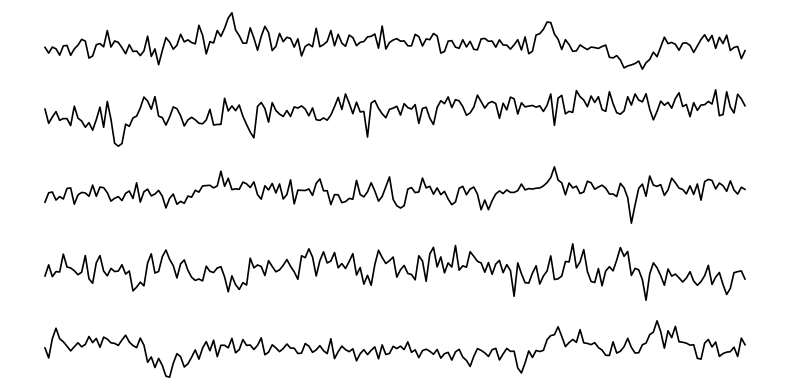

In [ ]:
import matplotlib.pyplot as plt

# --- Plot stacked signals only ---
fig, axes = plt.subplots(len(channels), 1, figsize=(8, 4), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(times, fake_raw[i], color='black', linewidth=1.2)
    
    # Hide everything
    ax.axis('off')

plt.tight_layout()
plt.show()


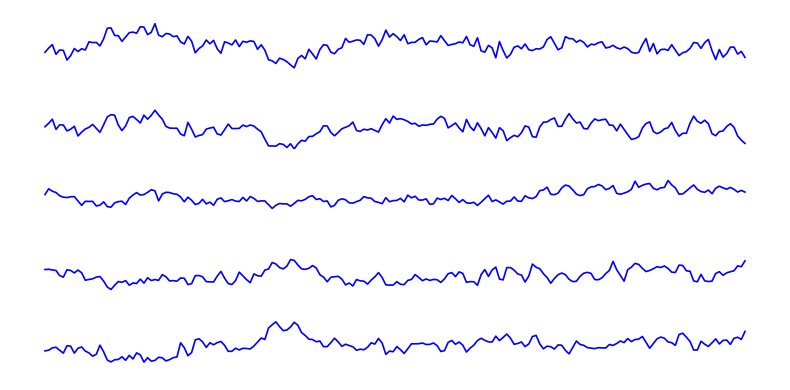

In [ ]:
import eelbrain
import numpy as np
import matplotlib.pyplot as plt

SUB = 'S13'
dst_dir = file_paths.EEG_DIR / SUB
eeg_dst = dst_dir / f"{SUB}_eeg.pickle"

# --- Load NDVar ---
eeg = eelbrain.load.unpickle(eeg_dst)

# --- Select channels ---
channels = ['Fp1', 'Fz', 'Cz', 'Pz', 'Oz']
eeg_sel = eeg.sub(sensor=channels)

# --- Crop first few seconds ---
eeg_crop = eeg_sel.sub(time=(0, 3))

# --- Average across trials if needed ---
if 'case' in eeg_crop.dims:
    eeg_crop = eeg_crop.mean('case')

# --- Extract data ---
data = eeg_crop.x.T
times = eeg_crop.time.times

# Convert to µV
data_uV = data * 1e6

# 🔥 Compute global y-scale from clean data
ymax = np.max(np.abs(data_uV))
ymin = -ymax

# --- Simulate “filtered but not fully preprocessed” ---
np.random.seed(123)
filtered_sim = np.zeros_like(data_uV)

for i in range(len(channels)):
    signal = data_uV[i]
    
    # Small perturbation
    perturb = np.random.normal(0, 0.05*ymax, size=signal.shape)
    
    filtered_sim[i] = signal + perturb

# --- Plot stacked signals (scaled, no axes) ---
fig, axes = plt.subplots(len(channels), 1, figsize=(8, 4), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(times, filtered_sim[i], color='blue', linewidth=1.2)
    
    # 🔥 Apply consistent scaling
    ax.set_ylim(ymin, ymax)
    
    # Hide everything visually
    ax.axis('off')

plt.tight_layout()
plt.show()


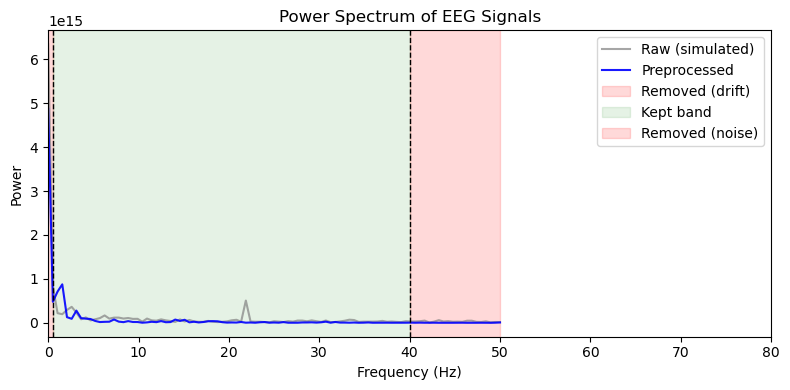

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sampling frequency (IMPORTANT: set correctly) ---
sfreq = 100  # Hz (adjust if needed)

# --- Compute power spectrum function ---
def compute_psd(signal, sfreq):
    n = signal.shape[-1]
    freqs = np.fft.rfftfreq(n, d=1/sfreq)
    psd = np.abs(np.fft.rfft(signal))**2 / n
    return freqs, psd

# --- Average PSD across channels ---
psd_raw = []
psd_clean = []

for i in range(len(channels)):
    f, p_raw = compute_psd(fake_raw[i], sfreq)
    _, p_clean = compute_psd(data_uV[i], sfreq)
    
    psd_raw.append(p_raw)
    psd_clean.append(p_clean)

psd_raw = np.mean(psd_raw, axis=0)
psd_clean = np.mean(psd_clean, axis=0)

# --- Plot ---
plt.figure(figsize=(8, 4))

# Plot spectra
plt.plot(f, psd_raw, color='grey', alpha=0.7, label='Raw (simulated)')
plt.plot(f, psd_clean, color='blue', alpha=0.9, label='Preprocessed')

# --- Highlight frequency bands ---
plt.axvspan(0, 0.5, color='red', alpha=0.15, label='Removed (drift)')
plt.axvspan(0.5, 40, color='green', alpha=0.1, label='Kept band')
plt.axvspan(40, f.max(), color='red', alpha=0.15, label='Removed (noise)')

# --- Draw cutoff lines ---
plt.axvline(0.5, color='black', linestyle='--', linewidth=1)
plt.axvline(40, color='black', linestyle='--', linewidth=1)

# --- Labels ---
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectrum of EEG Signals")

plt.legend(loc='upper right')
plt.xlim(0, 80)  # zoom into relevant range

plt.tight_layout()
plt.show()


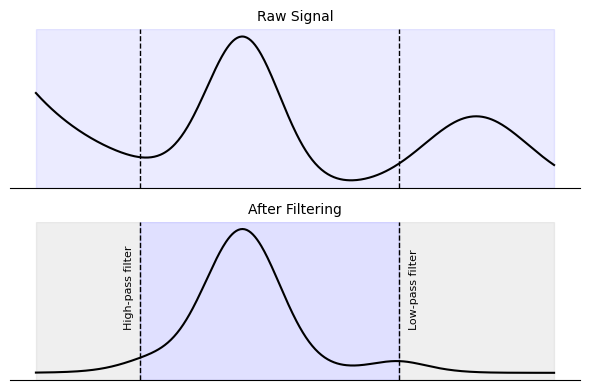

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fake "frequency axis" (purely conceptual)
x = np.linspace(0, 1, 500)

# --- Create illustrative raw spectrum ---
low = 2 * np.exp(-x * 6)
mid = 3 * np.exp(-(x - 0.4)**2 / 0.01)
high = 1.5 * np.exp(-(x - 0.85)**2 / 0.02)

raw = low + mid + high

# --- Define conceptual filter boundaries ---
hp_cut = 0.2
lp_cut = 0.7

# Smooth bandpass (visual only)
hp = 1 / (1 + np.exp(-(x - hp_cut)*30))
lp = 1 / (1 + np.exp((x - lp_cut)*30))
band = hp * lp

filtered = raw * band

# =========================================================
# 📊 Plot
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

# --- RAW ---
axes[0].plot(x, raw, color='black', linewidth=1.5)

# Entire spectrum is "present"
axes[0].axvspan(0, 1, color='blue', alpha=0.08)

# Show filter boundaries (for reference only)
axes[0].axvline(hp_cut, linestyle='--', color='black', linewidth=1)
axes[0].axvline(lp_cut, linestyle='--', color='black', linewidth=1)

axes[0].set_title("Raw Signal", fontsize=10)

# Clean look
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)

# --- FILTERED ---
axes[1].plot(x, filtered, color='black', linewidth=1.5)

# Background shading (now meaningful)
axes[1].axvspan(0, hp_cut, color='grey', alpha=0.12)
axes[1].axvspan(hp_cut, lp_cut, color='blue', alpha=0.12)
axes[1].axvspan(lp_cut, 1, color='grey', alpha=0.12)

# Filter boundary lines
axes[1].axvline(hp_cut, linestyle='--', color='black', linewidth=1)
axes[1].axvline(lp_cut, linestyle='--', color='black', linewidth=1)

# Labels (spaced nicely)
axes[1].text(hp_cut - 0.010, max(filtered)*0.3, "High-pass filter", 
             ha='right', va='bottom', fontsize=8, rotation=90)

axes[1].text(lp_cut + 0.020, max(filtered)*0.3, "Low-pass filter", 
             ha='left', va='bottom', fontsize=8, rotation=90)

axes[1].set_title("After Filtering", fontsize=10)

# Clean look
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)

plt.tight_layout()
plt.show()


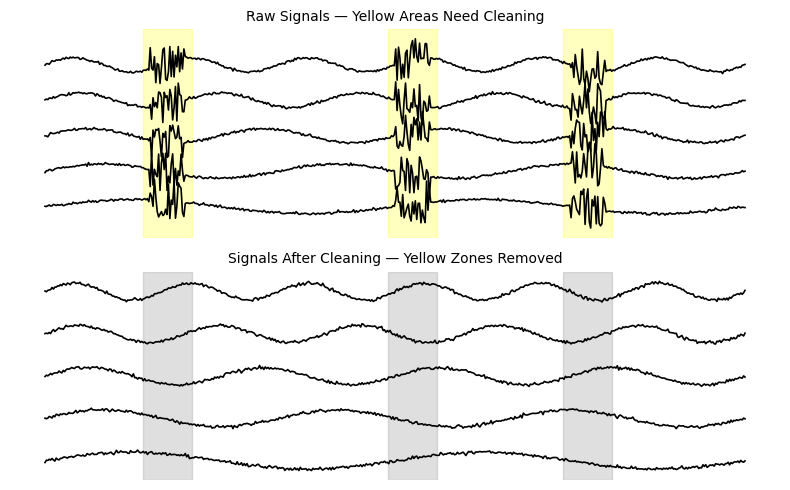

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Conceptual time axis ---
t = np.linspace(0, 1, 500)

channels = 5
raw_signals = np.zeros((channels, len(t)))
clean_signals = np.zeros_like(raw_signals)

# Amplitude for stacking
amp = 1.0

# Define bad segments (start, end in normalized time)
bad_segments = [(0.15,0.2), (0.5,0.55), (0.75,0.8)]

# --- Generate signals ---
np.random.seed(42)
for ch in range(channels):
    # Base smooth EEG-like signal
    base = 0.5*np.sin(2*np.pi*(2+ch)*t)
    
    # Small noise everywhere
    hf_noise = 0.05 * np.random.randn(len(t))
    
    # Start with base + noise
    raw = base + hf_noise
    
    # Add very obvious spikes in bad segments
    for start, end in bad_segments:
        idx = (t >= start) & (t <= end)
        raw[idx] += np.random.uniform(-1.5, 1.5, size=np.sum(idx))
    
    # Save raw and cleaned
    raw_signals[ch] = raw
    clean_signals[ch] = base + 0.05*np.random.randn(len(t))  # cleaned: bad segments removed / smoothed

# --- Vertical offsets to avoid collision ---
offsets = np.arange(channels) * (2*amp + 0.5)

# =========================================================
# 📊 Plot
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(8,5), sharex=True)

# --- RAW with bad segments highlighted ---
for ch in range(channels):
    axes[0].plot(t, raw_signals[ch] + offsets[ch], color='black', linewidth=1.2)

# Shade bad segments in red
for start, end in bad_segments:
    axes[0].axvspan(start-0.01, end+0.01, color='yellow', alpha=0.25)

axes[0].set_title("Raw Signals — Yellow Areas Need Cleaning", fontsize=10)
axes[0].axis('off')

# --- CLEANED: bad segments removed / smoothed ---
for ch in range(channels):
    axes[1].plot(t, clean_signals[ch] + offsets[ch], color='black', linewidth=1.2)

# Shade same zones in green to indicate they are now clean
for start, end in bad_segments:
    axes[1].axvspan(start-0.01, end+0.01, color='grey', alpha=0.25)

axes[1].set_title("Signals After Cleaning — Yellow Zones Removed", fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()




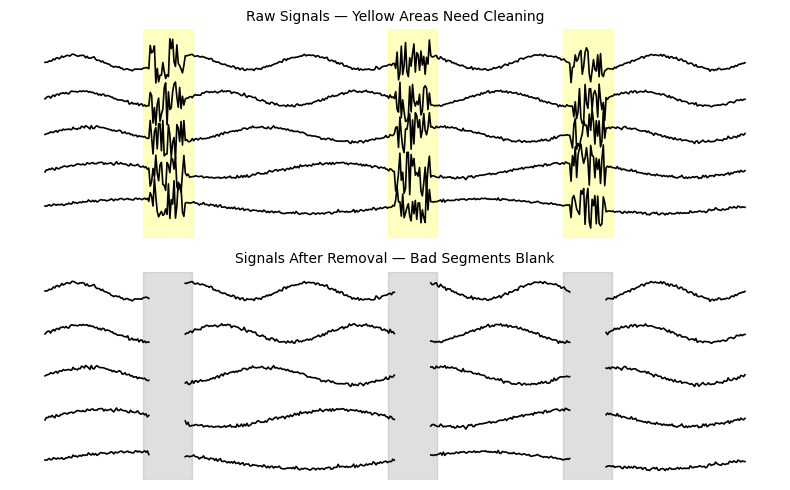

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Conceptual time axis ---
t = np.linspace(0, 1, 500)

channels = 5
raw_signals = np.zeros((channels, len(t)))
clean_signals = np.zeros_like(raw_signals)

# Amplitude for stacking
amp = 1.0

# Define bad segments (start, end in normalized time)
bad_segments = [(0.15,0.2), (0.5,0.55), (0.75,0.8)]

# --- Generate signals ---
np.random.seed(42)
for ch in range(channels):
    # Base smooth EEG-like signal
    base = 0.5*np.sin(2*np.pi*(2+ch)*t)
    
    # Small noise everywhere
    hf_noise = 0.05 * np.random.randn(len(t))
    
    # Start with base + noise
    raw = base + hf_noise
    
    # Add very obvious spikes in bad segments
    for start, end in bad_segments:
        idx = (t >= start) & (t <= end)
        raw[idx] += np.random.uniform(-1.5, 1.5, size=np.sum(idx))
    
    # Save raw
    raw_signals[ch] = raw
    
    # Cleaned: just remove bad segments (set to NaN)
    clean = np.copy(raw)
    for start, end in bad_segments:
        idx = (t >= start) & (t <= end)
        clean[idx] = np.nan
    clean_signals[ch] = clean

# --- Vertical offsets to avoid collision ---
offsets = np.arange(channels) * (2*amp + 0.5)

# =========================================================
# 📊 Plot
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(8,5), sharex=True)

# --- RAW with bad segments highlighted ---
for ch in range(channels):
    axes[0].plot(t, raw_signals[ch] + offsets[ch], color='black', linewidth=1.2)

# Shade bad segments in red
for start, end in bad_segments:
    axes[0].axvspan(start-0.01, end+0.01, color='yellow', alpha=0.25)

axes[0].set_title("Raw Signals — Yellow Areas Need Cleaning", fontsize=10)
axes[0].axis('off')

# --- CLEANED: bad segments removed ---
for ch in range(channels):
    axes[1].plot(t, clean_signals[ch] + offsets[ch], color='black', linewidth=1.2)

# Shade removed segments in red (optional to show gaps)
for start, end in bad_segments:
    axes[1].axvspan(start-0.01, end+0.01, color='grey', alpha=0.25)

axes[1].set_title("Signals After Removal — Bad Segments Blank", fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()


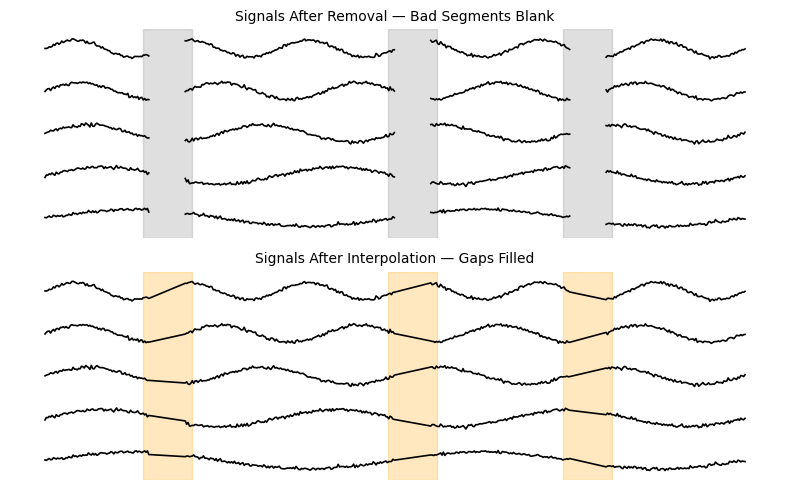

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Conceptual time axis ---
t = np.linspace(0, 1, 500)
channels = 5
amp = 1.0

# --- Bad segments (same as before) ---
bad_segments = [(0.15,0.2), (0.5,0.55), (0.75,0.8)]

# --- Generate “cleaned with gaps” signals (from previous step) ---
np.random.seed(42)
clean_signals = np.zeros((channels, len(t)))
for ch in range(channels):
    # Base signal
    base = 0.5*np.sin(2*np.pi*(2+ch)*t)
    hf_noise = 0.05 * np.random.randn(len(t))
    signal = base + hf_noise
    
    # Insert spikes in bad segments
    for start, end in bad_segments:
        idx = (t >= start) & (t <= end)
        signal[idx] += np.random.uniform(-1.5, 1.5, size=np.sum(idx))
    
    # Remove bad segments (set to NaN)
    for start, end in bad_segments:
        idx = (t >= start) & (t <= end)
        signal[idx] = np.nan
        
    clean_signals[ch] = signal

# --- Interpolate over NaN segments ---
interp_signals = np.copy(clean_signals)
for ch in range(channels):
    nans = np.isnan(interp_signals[ch])
    not_nans = ~nans
    interp_signals[ch, nans] = np.interp(t[nans], t[not_nans], interp_signals[ch, not_nans])

# --- Vertical offsets to avoid overlap ---
offsets = np.arange(channels) * (2*amp + 0.5)

# =========================================================
# 📊 Plot
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(8,5), sharex=True)

# --- Signals before interpolation (gaps) ---
for ch in range(channels):
    axes[0].plot(t, clean_signals[ch] + offsets[ch], color='black', linewidth=1.2)

# Shade removed segments
for start, end in bad_segments:
    axes[0].axvspan(start-0.01, end+0.01, color='grey', alpha=0.25)

axes[0].set_title("Signals After Removal — Bad Segments Blank", fontsize=10)
axes[0].axis('off')

# --- Signals after interpolation ---
for ch in range(channels):
    axes[1].plot(t, interp_signals[ch] + offsets[ch], color='black', linewidth=1.2)

# Optionally, keep red shading to indicate previously bad segments
for start, end in bad_segments:
    axes[1].axvspan(start-0.01, end+0.01, color='orange', alpha=0.25)

axes[1].set_title("Signals After Interpolation — Gaps Filled", fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()


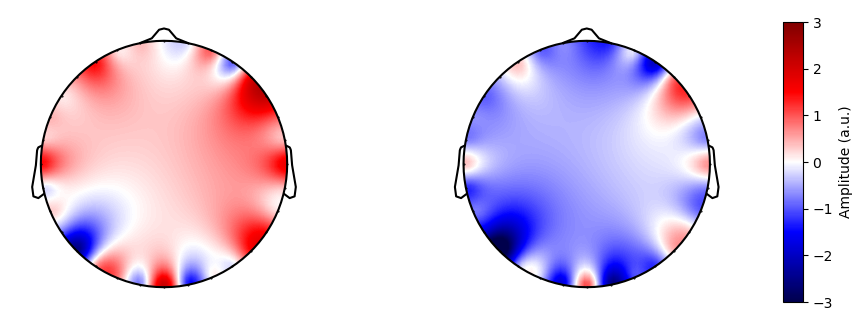

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import eelbrain
from eelbrain import NDVar, Sensor

# -----------------------------
# Fake EEG sensor layout (32 sensors in circle)
# -----------------------------
n_sensors = 32
theta = np.linspace(0, 2*np.pi, n_sensors, endpoint=False)
radius = 0.5
x = radius * np.cos(theta)
y = radius * np.sin(theta)
z = np.zeros_like(x)
locations = np.stack([x, y, z], axis=1)
sensors = Sensor(locations, names=[f'EEG{i+1}' for i in range(n_sensors)])

# -----------------------------
# Fake EEG values
# -----------------------------
np.random.seed(0)
values = np.random.randn(n_sensors)
topo_map = NDVar(values, dims=(sensors,))

# -----------------------------
# Mastoid reference
# -----------------------------
mastoid_idx = [n_sensors//4, 3*n_sensors//4]  # just an example
mastoid_mean = values[mastoid_idx].mean()
values_reref = values - mastoid_mean
topo_map_reref = NDVar(values_reref, dims=(sensors,))

# -----------------------------
# Plot comparison with colorbar
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Original
eelbrain.plot.Topomap(
    topo_map,
    axtitle='Original Fake EEG',
    axes=axes[0],
    clip='circle',
    cmap='seismic',
    vmin=-3, vmax=3
)

# Mastoid-referenced
eelbrain.plot.Topomap(
    topo_map_reref,
    axtitle='Mastoid-Referenced EEG',
    axes=axes[1],
    clip='circle',
    cmap='seismic',
    vmin=-3, vmax=3
)

# Shared colorbar
from matplotlib import cm, colors
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
norm = colors.Normalize(vmin=-3, vmax=3)
sm = cm.ScalarMappable(cmap='seismic', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Amplitude (a.u.)')

plt.show()



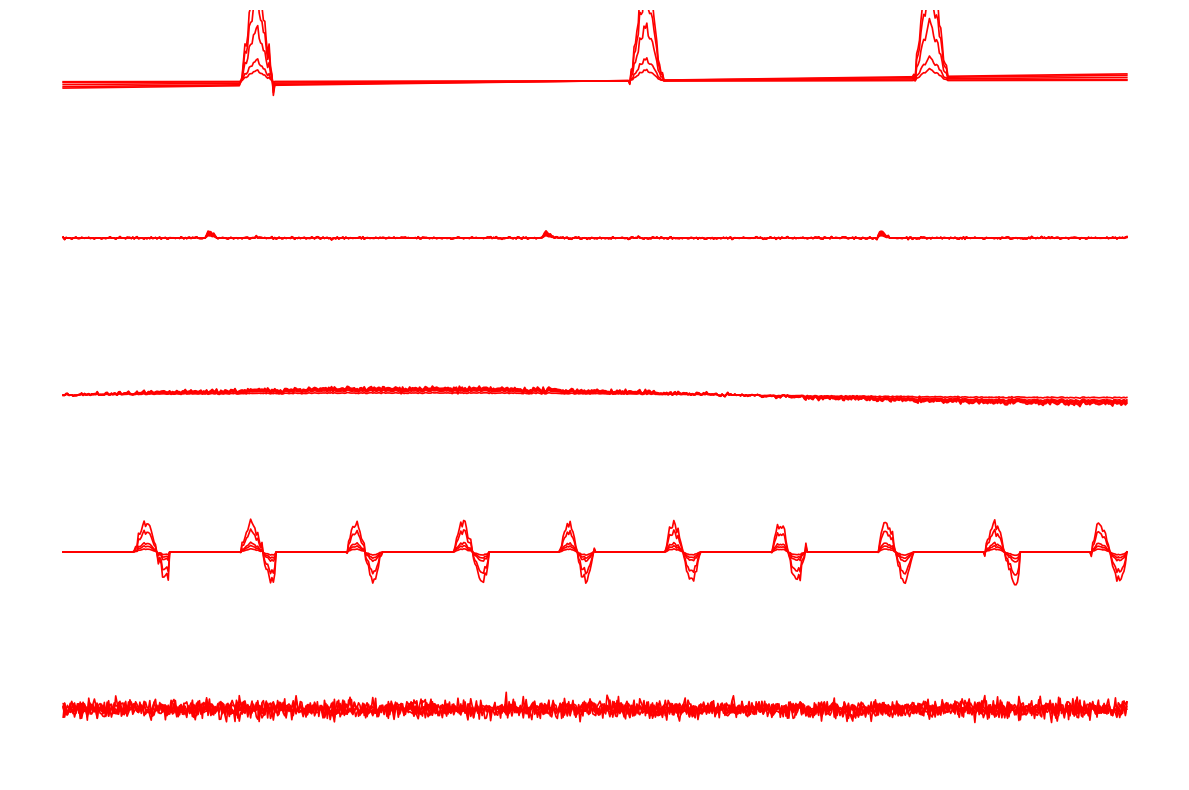

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
channels = ['Fp1', 'Fz', 'Cz', 'Pz', 'Oz']
n_ch = len(channels)
fs = 250  # Hz
t = np.linspace(0, 3, 3*fs)  # 3 seconds
ymax = 50  # µV
np.random.seed(42)

# -----------------------------
# ICA-like components
# -----------------------------
ica_components = {}

# 1. Eye Blink (keep as is)
blink_base = np.zeros_like(t)
blink_times = [0.5, 1.6, 2.4]
for bt in blink_times:
    idx = np.abs(t - bt).argmin()
    shape = np.concatenate([np.linspace(0, 80, 12), np.linspace(80, 0, 12)])
    shape += np.random.normal(0, 5, len(shape))
    blink_base[idx:idx+24] += shape
blink_base += np.linspace(-5,5,len(t))  # slight drift
ica_components['Eye Blink'] = np.array([
    blink_base*1.0, blink_base*0.8, blink_base*0.5, blink_base*0.2, blink_base*0.1
])

# 2. Heartbeat (keep as is)
hb = np.zeros_like(t)
hb_times = np.arange(0.4, t[-1], 0.95 + 0.05*np.random.randn(1)[0])
for bt in hb_times:
    idx = np.abs(t - bt).argmin()
    peak = np.concatenate([np.linspace(0,15,3), np.linspace(15,0,7)])
    hb[idx:idx+10] += peak
hb += np.random.normal(0,1.5,len(t))  # small noise
ica_components['Heartbeat'] = np.array([
    hb*0.3, hb*0.25, hb*0.2, hb*0.15, hb*0.1
])

# 3. Respiration (keep as is)
resp = 15 * np.sin(2*np.pi*0.25*t + 0.3*np.sin(2*np.pi*0.05*t))
resp *= np.linspace(0.8,1.2,len(t))  # amplitude drift
resp += np.random.normal(0,2,len(t))
ica_components['Respiration'] = np.array([resp*0.3, resp*0.35, resp*0.25, resp*0.2, resp*0.1])

# 4. Posterior Alpha (REALISTIC)
alpha_base = np.zeros_like(t)
# generate bursts of alpha rhythm
for burst_start in np.arange(0.2, 3, 0.3):
    idx = np.abs(t - burst_start).argmin()
    burst_len = int(0.1 * fs)  # ~100 ms bursts
    freq = 9 + np.random.randn()  # 9-10 Hz with jitter
    burst_t = t[:burst_len]
    alpha_wave = 20 * np.sin(2*np.pi*freq*burst_t)
    alpha_wave += np.random.normal(0,2,len(alpha_wave))  # noise
    if idx+burst_len < len(t):
        alpha_base[idx:idx+burst_len] += alpha_wave
ica_components['Posterior Alpha'] = np.array([
    alpha_base*0.1, alpha_base*0.2, alpha_base*0.3, alpha_base*0.7, alpha_base*1.0
])

# 5. Muscle (keep as is)
muscle = 3 * np.random.randn(n_ch, len(t))
ica_components['Muscle'] = muscle

# -----------------------------
# Plot ICA components
# -----------------------------
fig, axes = plt.subplots(len(ica_components), 1, figsize=(12, 8), sharex=True)

for i, (name, comp) in enumerate(ica_components.items()):
    for ch in range(n_ch):
        axes[i].plot(t, comp[ch], color='red', lw=1.2)
    axes[i].set_ylim(-ymax, ymax)
    axes[i].set_ylabel(name, fontsize=10)
    axes[i].axis('off')

axes[-1].set_xlabel('Time (s)', fontsize=12)
plt.tight_layout()
plt.show()






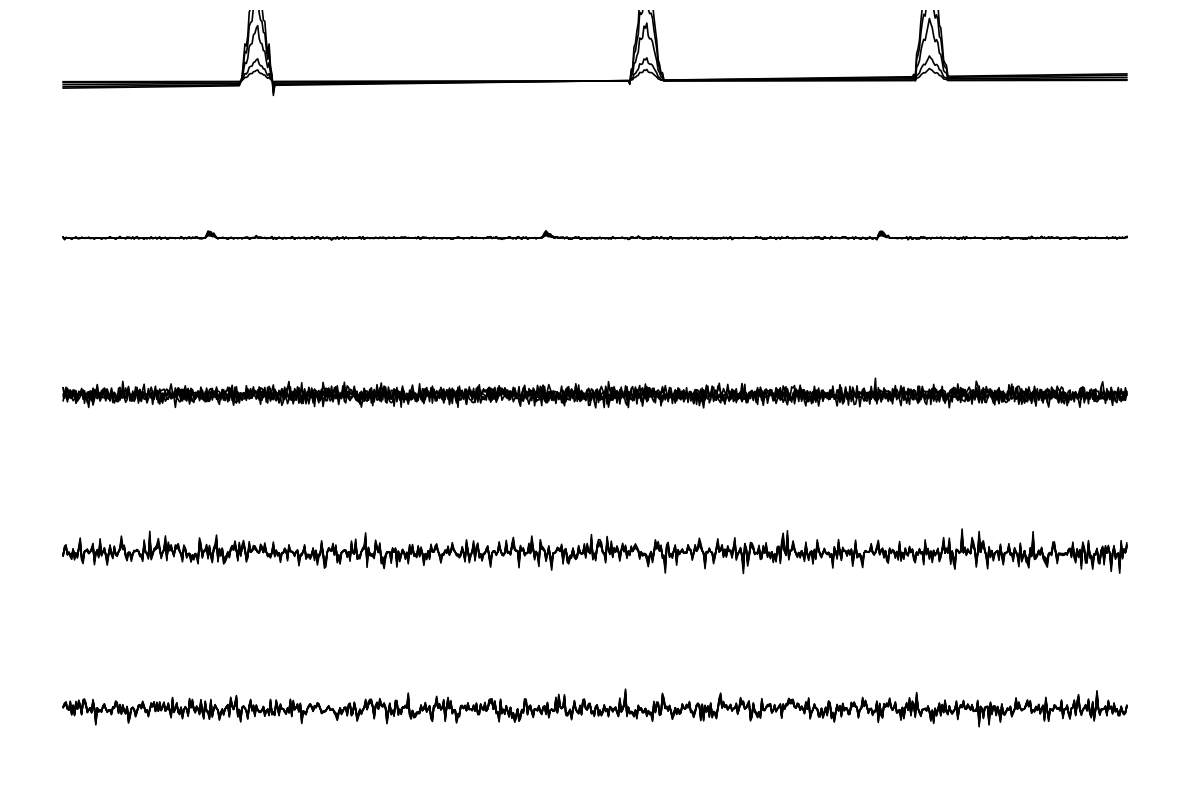

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
channels = ['Fp1', 'Fz', 'Cz', 'Pz', 'Oz']
n_ch = len(channels)
fs = 250  # Hz
t = np.linspace(0, 3, 3*fs)  # 3 seconds
ymax = 50  # µV
np.random.seed(42)

# -----------------------------
# ICA-like components
# -----------------------------
ica_components = {}

# 1. Eye Blink
blink_base = np.zeros_like(t)
blink_times = [0.5, 1.6, 2.4]
for bt in blink_times:
    idx = np.abs(t - bt).argmin()
    shape = np.concatenate([np.linspace(0, 80, 12), np.linspace(80, 0, 12)])
    shape += np.random.normal(0, 5, len(shape))
    blink_base[idx:idx+24] += shape
blink_base += np.linspace(-5,5,len(t))
ica_components['Eye Blink'] = np.array([
    blink_base*1.0, blink_base*0.8, blink_base*0.5, blink_base*0.2, blink_base*0.1
])

# 2. Heartbeat
hb = np.zeros_like(t)
hb_times = np.arange(0.4, t[-1], 0.95 + 0.05*np.random.randn(1)[0])
for bt in hb_times:
    idx = np.abs(t - bt).argmin()
    peak = np.concatenate([np.linspace(0,15,3), np.linspace(15,0,7)])
    hb[idx:idx+10] += peak
hb += np.random.normal(0,1.5,len(t))
ica_components['Heartbeat'] = np.array([
    hb*0.3, hb*0.25, hb*0.2, hb*0.15, hb*0.1
])

# 3. Muscle
muscle = 3 * np.random.randn(n_ch, len(t))
ica_components['Muscle'] = muscle

# 4. Auditory / Speech Component 1
speech1 = np.sin(2*np.pi*4*t) * np.random.uniform(0.8, 1.2, len(t))  # ~4 Hz syllable rhythm
speech1 += np.random.normal(0, 5, len(t))
ica_components['Auditory Comp 1'] = np.array([
    speech1*0.7, speech1*0.8, speech1*1.0, speech1*0.6, speech1*0.5
])

# 5. Auditory / Listening Component 2
speech2 = np.sin(2*np.pi*6*t + 0.5*np.sin(2*np.pi*0.3*t))  # 6 Hz with slow modulation
speech2 *= np.random.uniform(0.8, 1.2, len(t))
speech2 += np.random.normal(0, 4, len(t))
ica_components['Auditory Comp 2'] = np.array([
    speech2*1.0, speech2*0.9, speech2*0.8, speech2*0.7, speech2*0.6
])

# -----------------------------
# Plot ICA components
# -----------------------------
fig, axes = plt.subplots(len(ica_components), 1, figsize=(12, 8), sharex=True)

for i, (name, comp) in enumerate(ica_components.items()):
    for ch in range(n_ch):
        axes[i].plot(t, comp[ch], color='black', lw=1.2)
    axes[i].set_ylim(-ymax, ymax)
    axes[i].set_ylabel(name, fontsize=10)
    axes[i].axis('off')

axes[-1].set_xlabel('Time (s)', fontsize=12)
plt.tight_layout()
plt.show()
